# Oslo Bysykkel: Forecasting

Downloads the hourly weather forecast for Blindern from the MET Norway Locationforecast API, engineers the same features used during training, and produces a 9-day hourly trip count forecast using two XGBoost models (one for weekdays and one for weekends). 

The only trip-count-derived feature is `prev_year_trips` (the total number of trips taken in the previous calendar year) which is always fully available at forecast time without needing recent trip data.

**Inputs:**
- `output/model_weekday.joblib` — trained XGBoost model for weekday hours
- `output/model_weekend.joblib` — trained XGBoost model for weekend hours

**Output:** `output/forecasts/9day_<timestamp>.csv` + inline plots

## 0 · Configuration

In [1]:
from pathlib import Path

MODEL_WEEKDAY_PATH = Path("output/model_weekday.joblib")
MODEL_WEEKEND_PATH = Path("output/model_weekend.joblib")
OUTPUT_DIR         = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# Blindern weather station — official reference station for Oslo
LAT, LON, ALT = 59.9423, 10.7200, 94

# MET Norway requires a descriptive User-Agent (name + contact)
USER_AGENT = "BysykkelForecast"

FORECAST_DAYS = 9

HOLIDAYS_PATH = Path("input/oslo_holidays_2020_2027.csv")

# Total trips taken in the previous calendar year.
# Update this value each January once the annual Bysykkel data is available.
PREV_YEAR_TRIPS = 1112055   # 2025 total
# (hardcoded here because the trip data is not part of the GitHub repository)

## 1 · Imports

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
import joblib

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

In [3]:
print(f"PREV_YEAR_TRIPS = {PREV_YEAR_TRIPS:,}")

PREV_YEAR_TRIPS = 1,112,055


## 2 · Load trained models

In [4]:
wd_bundle = joblib.load(MODEL_WEEKDAY_PATH)
we_bundle = joblib.load(MODEL_WEEKEND_PATH)

weekday_model    = wd_bundle["model"]
weekend_model    = we_bundle["model"]
FEATURE_COLS     = wd_bundle["features"]   # same for both models

print(f"Weekday model : {wd_bundle.get('name', 'XGBoost')}  ({len(FEATURE_COLS)} features)")
print(f"Weekend model : {we_bundle.get('name', 'XGBoost')}  ({len(we_bundle['features'])} features)")
print(f"\nFeatures: {FEATURE_COLS}")

Weekday model : XGBoost Weekday  (16 features)
Weekend model : XGBoost Weekend  (16 features)

Features: ['temp_c', 'precip_mm', 'wind_speed_ms', 'cloud_area_fraction', 'hour_of_day', 'day_of_week', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'precip_mm_lag1h', 'prev_year_trips', 'is_school_holiday', 'is_national_holiday']


## 3 · Fetch weather forecast from MET Norway

Uses the `complete` endpoint of Locationforecast 2.0. Precipitation is taken from `next_1_hours` for the first ~60 hours and `next_6_hours` beyond that (forward-filled to hourly). 

In [5]:
def fetch_forecast(lat, lon, alt, user_agent):
    url = (
        f"https://api.met.no/weatherapi/locationforecast/2.0/complete"
        f"?lat={lat:.4f}&lon={lon:.4f}&altitude={alt}"
    )
    resp = requests.get(url, headers={"User-Agent": user_agent}, timeout=20)
    resp.raise_for_status()

    rows = []
    for entry in resp.json()["properties"]["timeseries"]:
        t       = pd.Timestamp(entry["time"]).tz_convert("Europe/Oslo").tz_localize(None)
        instant = entry["data"]["instant"]["details"]

        precip = None
        for window in ("next_1_hours", "next_6_hours", "next_12_hours"):
            if window in entry["data"]:
                precip = entry["data"][window]["details"].get("precipitation_amount")
                break

        rows.append({
            "hour":                t,
            "temp_c":              instant.get("air_temperature"),
            "wind_speed_ms":       instant.get("wind_speed"),
            "cloud_area_fraction": instant.get("cloud_area_fraction"),
            "precip_mm":           precip,
        })

    df = pd.DataFrame(rows).set_index("hour")
    df["precip_mm"] = df["precip_mm"].ffill()

    start    = df.index[0]
    end      = start + pd.Timedelta(days=FORECAST_DAYS)
    df       = df.loc[start:end]
    full_idx = pd.date_range(start, end, freq="h", inclusive="left")
    df       = df.reindex(full_idx).interpolate("time")
    df.index.name = "hour"
    return df.reset_index()

fetch_time   = pd.Timestamp.now(tz="Europe/Oslo")
raw_forecast = fetch_forecast(LAT, LON, ALT, USER_AGENT)
print(f"Fetched  : {fetch_time:%Y-%m-%d %H:%M} Oslo time")
print(f"Forecast : {len(raw_forecast)} hours  "
      f"({raw_forecast['hour'].min()} → {raw_forecast['hour'].max()})")
raw_forecast.head(12)

Fetched  : 2026-04-15 17:09 Oslo time
Forecast : 216 hours  (2026-04-15 16:00:00 → 2026-04-24 15:00:00)


,hour,temp_c,wind_speed_ms,cloud_area_fraction,precip_mm
0,2026-04-15 16:00:00,12.3,2.8,77.1,0.0
1,2026-04-15 17:00:00,12.0,3.1,75.7,0.0
2,2026-04-15 18:00:00,12.2,3.3,77.9,0.0
3,2026-04-15 19:00:00,11.8,3.0,59.9,0.0
4,2026-04-15 20:00:00,10.7,2.8,83.0,0.0
5,2026-04-15 21:00:00,9.4,2.8,57.0,0.0
6,2026-04-15 22:00:00,8.2,3.3,67.1,0.0
7,2026-04-15 23:00:00,7.6,3.6,98.9,0.0
8,2026-04-16 00:00:00,7.1,3.7,55.6,0.0
9,2026-04-16 01:00:00,6.5,3.5,35.6,0.0


## 4 · Engineer features

Mirrors the training pipeline exactly. Weather lags come from the forecast itself (earlier hours in the 9-day window, back-filled for the first few slots). `prev_year_trips` is hardcoded above, no historical trip data required (but needs to be updated at the beginning of a new year). 

In [6]:
# Load Oslo school holidays for feature engineering
_hol = pd.read_csv(HOLIDAYS_PATH)
_hol["date"] = pd.to_datetime(_hol["date"], format="%d-%m-%Y").dt.date
SCHOOL_HOLIDAY_DATES   = set(_hol.loc[_hol["oslo_school_holiday"],   "date"])
NATIONAL_HOLIDAY_DATES = set(_hol.loc[_hol["national_holiday"],      "date"])

print(f"School holidays loaded  : {len(SCHOOL_HOLIDAY_DATES)} days")
print(f"National holidays loaded: {len(NATIONAL_HOLIDAY_DATES)} days")
print(f"Date range: {min(SCHOOL_HOLIDAY_DATES)} → {max(SCHOOL_HOLIDAY_DATES)}")

School holidays loaded  : 720 days
National holidays loaded: 95 days
Date range: 2020-01-01 → 2027-12-31


In [7]:
def cyclical(series, period):
    rad = 2 * np.pi * series / period
    return np.sin(rad), np.cos(rad)

def engineer_features(df: pd.DataFrame, prev_year_trips: float) -> pd.DataFrame:
    df = df.copy()

    # ── Calendar ──────────────────────────────────────────────────────────
    df["hour_of_day"] = df["hour"].dt.hour
    df["day_of_week"] = df["hour"].dt.dayofweek
    df["month"]       = df["hour"].dt.month

    # ── Cyclical encodings ─────────────────────────────────────────────────
    df["hour_sin"],  df["hour_cos"]  = cyclical(df["hour_of_day"], 24)
    df["month_sin"], df["month_cos"] = cyclical(df["month"], 12)
    df["day_of_year"]                = df["hour"].dt.dayofyear
    df["doy_sin"],   df["doy_cos"]   = cyclical(df["day_of_year"], 365)

    # ── 1-hour precipitation lag ───────────────────────────────────────────
    df["precip_mm_lag1h"] = df["precip_mm"].shift(1).bfill()

    # ── Previous year trips ────────────────────────────────────────────────
    df["prev_year_trips"] = prev_year_trips

    # ── Holiday flags ──────────────────────────────────────────────────────
    df["is_school_holiday"]   = df["hour"].dt.date.map(
        lambda d: int(d in SCHOOL_HOLIDAY_DATES))
    df["is_national_holiday"] = df["hour"].dt.date.map(
        lambda d: int(d in NATIONAL_HOLIDAY_DATES))

    # ── Consecutive dry days (within forecast window, starting from 0) ─────
    daily_precip = (
        df.groupby(df["hour"].dt.date)["precip_mm"]
        .sum()
        .reset_index()
        .rename(columns={"hour": "date", "precip_mm": "daily_precip_mm"})
    )
    consecutive, count = [], 0
    for is_dry in (daily_precip["daily_precip_mm"] < 1.0):
        count = count + 1 if is_dry else 0
        consecutive.append(count)
    daily_precip["consecutive_dry_days"] = consecutive
    date_to_cdd = daily_precip.set_index("date")["consecutive_dry_days"].to_dict()
    df["consecutive_dry_days"] = df["hour"].dt.date.map(date_to_cdd)

    return df

forecast_features = engineer_features(raw_forecast, PREV_YEAR_TRIPS)

missing = forecast_features[FEATURE_COLS].isna().sum()
missing = missing[missing > 0]
if missing.empty:
    print("All features populated — no missing values.")
else:
    print("⚠ Missing values:")
    print(missing)

All features populated — no missing values.


## 5 · Generate forecast

In [8]:
CLOSED_HOURS = [1, 2, 3, 4]   # 01:00–04:59 Oslo time — no trips possible

is_closed  = forecast_features["hour"].dt.hour.isin(CLOSED_HOURS)
is_weekend = forecast_features["hour"].dt.dayofweek.isin([5, 6])

predicted = np.zeros(len(forecast_features))   # closed hours stay at 0

open_weekday = ~is_closed & ~is_weekend
open_weekend = ~is_closed &  is_weekend

predicted[open_weekday] = weekday_model.predict(forecast_features.loc[open_weekday, FEATURE_COLS].values)
predicted[open_weekend] = weekend_model.predict(forecast_features.loc[open_weekend,  FEATURE_COLS].values)
predicted = np.clip(predicted, 0, None).round().astype(int)

forecast = forecast_features[["hour"]].copy()
forecast["predicted_trips"] = predicted
for col in ["temp_c", "precip_mm", "wind_speed_ms", "cloud_area_fraction",
            "is_school_holiday", "is_national_holiday"]:
    forecast[col] = forecast_features[col].values

print(f"Total predicted trips over 9 days: {forecast['predicted_trips'].sum():,}")
forecast.head(24)

Total predicted trips over 9 days: 32,860


,hour,predicted_trips,temp_c,precip_mm,wind_speed_ms,cloud_area_fraction,is_school_holiday,is_national_holiday
0,2026-04-15 16:00:00,443,12.3,0.0,2.8,77.1,0,0
1,2026-04-15 17:00:00,354,12.0,0.0,3.1,75.7,0,0
2,2026-04-15 18:00:00,289,12.2,0.0,3.3,77.9,0,0
3,2026-04-15 19:00:00,202,11.8,0.0,3.0,59.9,0,0
4,2026-04-15 20:00:00,153,10.7,0.0,2.8,83.0,0,0
5,2026-04-15 21:00:00,126,9.4,0.0,2.8,57.0,0,0
6,2026-04-15 22:00:00,88,8.2,0.0,3.3,67.1,0,0
7,2026-04-15 23:00:00,57,7.6,0.0,3.6,98.9,0,0
8,2026-04-16 00:00:00,21,7.1,0.0,3.7,55.6,0,0
9,2026-04-16 01:00:00,0,6.5,0.0,3.5,35.6,0,0


## 6 · Daily summary

In [9]:
# Service day: 05:00 on day D through 00:00 on day D+1 (hours 01–04 closed)
svc = forecast[~forecast["hour"].dt.hour.isin([1, 2, 3, 4])].copy()
svc["service_day"] = (svc["hour"] - pd.Timedelta(hours=5)).dt.date

# Only include service days with a complete 20-hour forecast
counts = svc.groupby("service_day")["hour"].transform("count")
svc = svc[counts == 20]

daily = (
    svc.groupby("service_day")
    .agg(
        total_trips    = ("predicted_trips",    "sum"),
        peak_trips_hr  = ("predicted_trips",    "max"),
        avg_temp_c     = ("temp_c",             "mean"),
        total_precip   = ("precip_mm",          "sum"),
        avg_cloud_pct  = ("cloud_area_fraction", "mean"),
    )
    .reset_index()
    .rename(columns={"service_day": "date"})
)
daily["avg_temp_c"]    = daily["avg_temp_c"].round(1)
daily["total_precip"]  = daily["total_precip"].round(1)
daily["avg_cloud_pct"] = daily["avg_cloud_pct"].round(0).astype(int)
print(daily.to_string(index=False))

      date  total_trips  peak_trips_hr  avg_temp_c  total_precip  avg_cloud_pct
2026-04-16         3581            438         9.4           0.0             62
2026-04-17         3732            422        10.4           0.0             85
2026-04-18         1407            113        10.2          33.0            100
2026-04-19          956             83         9.1          35.6            100
2026-04-20         4418            545        10.1           0.0             34
2026-04-21         4945            570        12.4           0.0             10
2026-04-22         4885            560        12.3           0.0             73
2026-04-23         4727            555         9.9           0.0             39


## 7 · Visualise

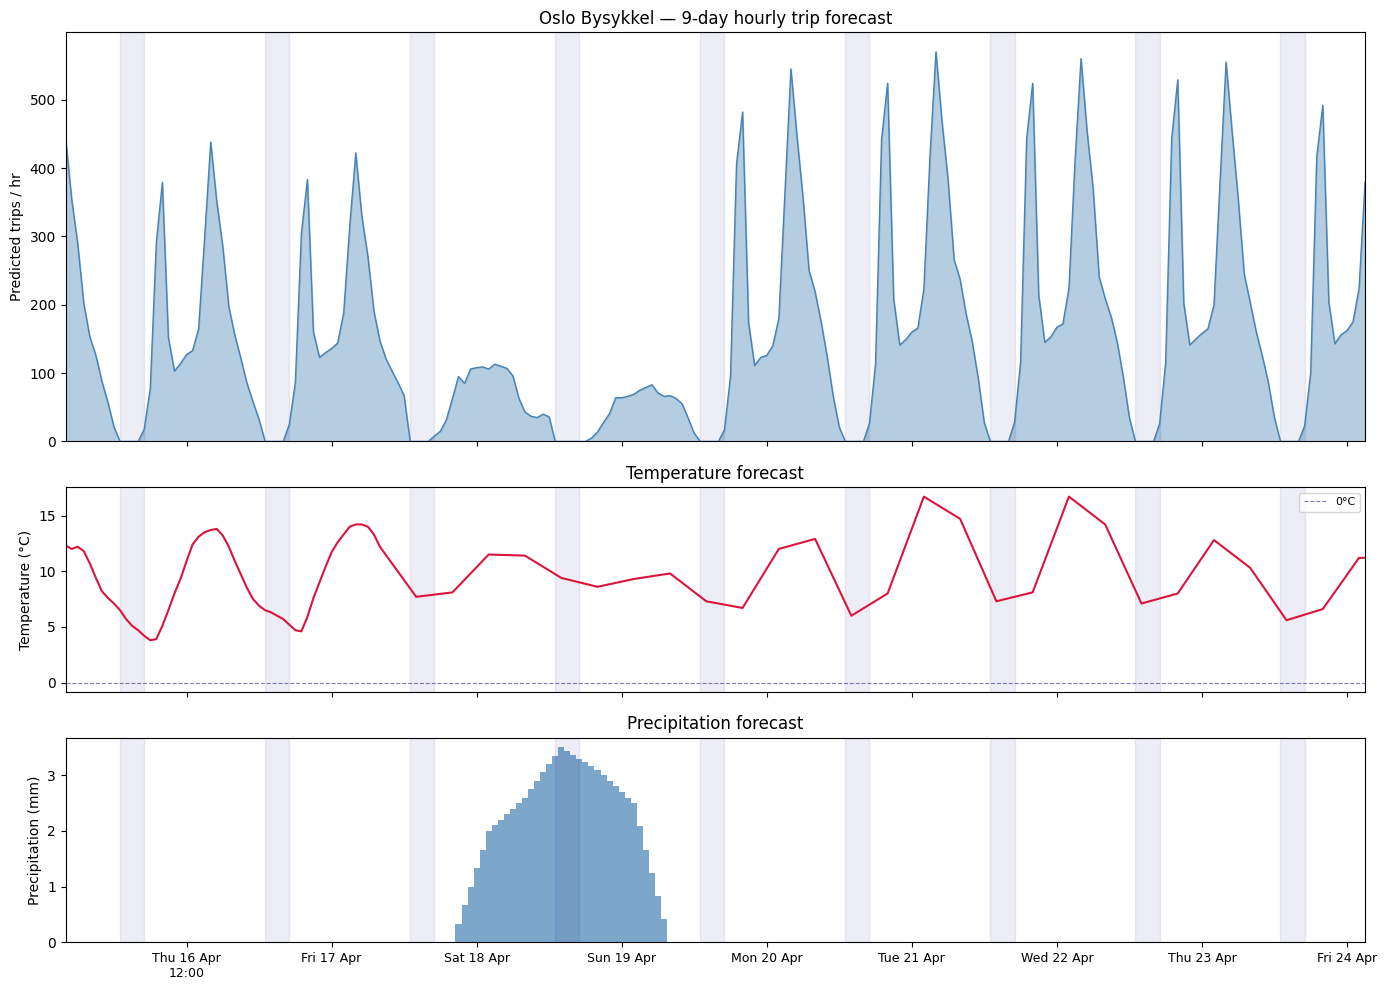

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1, 1]})

x_min, x_max = forecast["hour"].min(), forecast["hour"].max()

# Noon ticks — centred under each day; first tick includes the time label
noon_ticks = [
    d + pd.Timedelta(hours=12)
    for d in pd.date_range(x_min.normalize(), x_max.normalize(), freq="D")
    if d + pd.Timedelta(hours=12) >= x_min
]
tick_labels = [
    t.strftime("%a %-d %b\n%H:%M") if i == 0 else t.strftime("%a %-d %b")
    for i, t in enumerate(noon_ticks)
]

# Closure bands applied to every subplot
def add_closure_bands(ax):
    for day_start in pd.date_range(x_min.normalize(), x_max.normalize(), freq="D"):
        ax.axvspan(day_start + pd.Timedelta(hours=1),
                   day_start + pd.Timedelta(hours=5), alpha=0.07, color="navy")

# ── Trips ──────────────────────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(forecast["hour"], forecast["predicted_trips"], alpha=0.4, color="steelblue")
ax.plot(forecast["hour"], forecast["predicted_trips"], color="steelblue", lw=1)
ax.set_ylabel("Predicted trips / hr")
ax.set_ylim(bottom=0)
ax.set_title("Oslo Bysykkel — 9-day hourly trip forecast")
add_closure_bands(ax)

# ── Temperature ────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(forecast["hour"], forecast["temp_c"], color="crimson", lw=1.5)
ax.axhline(0, color="navy", lw=0.8, linestyle="--", alpha=0.5, label="0°C")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Temperature forecast")
ax.legend(fontsize=8)
add_closure_bands(ax)

# ── Precipitation ──────────────────────────────────────────────────────────
ax = axes[2]
ax.bar(forecast["hour"], forecast["precip_mm"], width=1/24, color="steelblue", alpha=0.7)
ax.set_ylabel("Precipitation (mm)")
ax.set_title("Precipitation forecast")
ax.set_ylim(bottom=0)
add_closure_bands(ax)

# ── Shared x-axis ──────────────────────────────────────────────────────────
axes[2].set_xlim(x_min, x_max)
axes[2].set_xticks(noon_ticks)
axes[2].set_xticklabels(tick_labels, ha="center", fontsize=9)

plt.tight_layout()
plt.show()

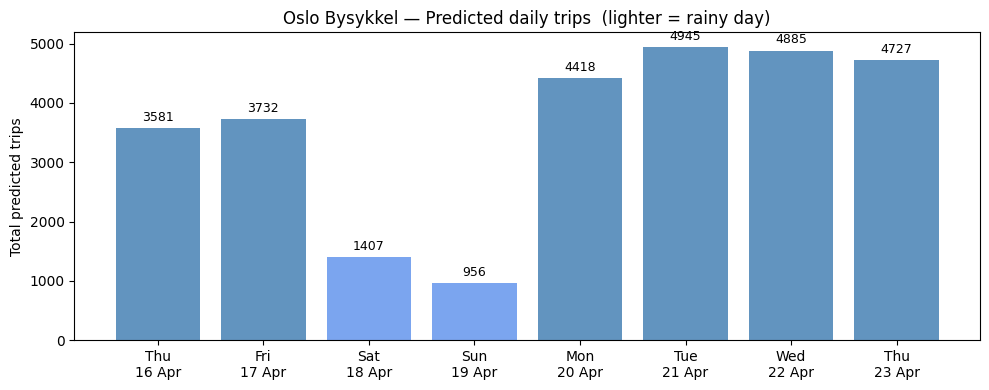

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["cornflowerblue" if p > 1 else "steelblue" for p in daily["total_precip"]]
bars = ax.bar(
    [pd.Timestamp(d).strftime("%a\n%-d %b") for d in daily["date"]],
    daily["total_trips"], color=colors, alpha=0.85,
)
ax.bar_label(bars, fmt="%d", padding=3, fontsize=9)
ax.set_ylabel("Total predicted trips")
ax.set_title("Oslo Bysykkel — Predicted daily trips  (lighter = rainy day)")
ax.set_ylim(bottom=0)
plt.xticks(rotation=0, ha="center")
plt.tight_layout()
plt.show()

## 8 · Save

In [12]:
FORECAST_DIR = OUTPUT_DIR / "forecasts"
FORECAST_DIR.mkdir(exist_ok=True)

out_path = FORECAST_DIR / f"9day_{fetch_time:%d%m%y-%H.%M}.csv"
forecast.to_csv(out_path, index=False)
print(f"Saved → {out_path.resolve()}")
print(f"Shape  : {forecast.shape[0]} rows × {forecast.shape[1]} columns")

Saved → /Users/dylan/Projects/BysykkelForecast/output/forecasts/9day_150426-17.09.csv
Shape  : 216 rows × 8 columns
